# Exploratory Data Analysis:

---

In [1]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.preprocessing import FunctionTransformer

In [2]:
data = pd.read_csv("house_prices.csv")

In [3]:
print(f"Rows: {data.shape[0]}\nColumns: {data.shape[1]}")

Rows: 1020
Columns: 14


In [4]:
print(f"Duplicated Values: {data.duplicated().sum()}")

Duplicated Values: 0


In [5]:
print(f"Missing Values:\n{((data.isna().sum()/len(data) * 100).round(3)).sort_values(ascending=False)}")

Missing Values:
MonthlyHOAFee     5.098
Age               5.000
Area              4.902
Garage            4.902
HouseID           0.000
Bedrooms          0.000
Bathrooms         0.000
Floors            0.000
Neighborhood      0.000
Condition         0.000
DistanceToCity    0.000
HasGarden         0.000
SalePrice         0.000
InspectionCode    0.000
dtype: float64


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   HouseID         1020 non-null   int64  
 1   Area            970 non-null    float64
 2   Bedrooms        1020 non-null   int64  
 3   Bathrooms       1020 non-null   int64  
 4   Floors          1020 non-null   int64  
 5   Age             969 non-null    float64
 6   Garage          970 non-null    object 
 7   Neighborhood    1020 non-null   object 
 8   Condition       1020 non-null   object 
 9   DistanceToCity  1020 non-null   float64
 10  HasGarden       1020 non-null   object 
 11  MonthlyHOAFee   968 non-null    float64
 12  SalePrice       1020 non-null   int64  
 13  InspectionCode  1020 non-null   object 
dtypes: float64(4), int64(5), object(5)
memory usage: 111.7+ KB


In [7]:
data.describe()

,HouseID,Area,Bedrooms,Bathrooms,Floors,Age,DistanceToCity,MonthlyHOAFee,SalePrice
count,1020.000000,970.000000,1020.000000,1020.000000,1020.000000,969.000000,1020.000000,968.000000,1.020000e+03
mean,1502.918627,2628.512371,2.961765,2.469608,1.986275,24.670795,15.270078,3249.952479,2.088264e+06
std,288.735731,1264.562063,1.420966,1.139038,0.822767,14.459761,8.413788,1625.309809,6.614282e+05
min,1001.000000,601.000000,1.000000,1.000000,1.000000,0.000000,1.010000,502.000000,1.393160e+05
25%,1253.750000,1646.500000,2.000000,1.000000,1.000000,12.000000,7.995000,1859.750000,1.640298e+06
50%,1505.500000,2506.750000,3.000000,2.000000,2.000000,25.000000,15.020000,3199.500000,2.090106e+06
75%,1752.250000,3594.500000,4.000000,4.000000,3.000000,37.000000,22.900000,4755.250000,2.477810e+06
max,2000.000000,11135.000000,5.000000,4.000000,3.000000,49.000000,29.980000,5997.000000,5.866954e+06


In [8]:
data.sample(10)

,HouseID,Area,Bedrooms,Bathrooms,Floors,Age,Garage,Neighborhood,Condition,DistanceToCity,HasGarden,MonthlyHOAFee,SalePrice,InspectionCode
447,1448,1258.0,5,4,1,2.0,Yes,Riverside,Good,17.50,No,730.0,2576397,INSP1203
261,1262,2231.0,2,3,3,10.0,Yes,Downtown,Good,21.11,Yes,4008.0,2328452,INSP1196
658,1659,3449.0,1,2,1,2.0,Yes,Downtown,Fair,24.95,Yes,1488.0,1622313,INSP1095
819,1820,1797.0,3,2,2,40.0,No,Downtown,Fair,14.74,Yes,1536.0,1610376,INSP1181
806,1807,1332.0,5,3,3,4.0,Yes,Riverside,Fair,15.44,Yes,4795.0,2841484,INSP1124
927,1928,957.0,5,1,3,48.0,No,Suburb,Excellent,27.41,No,4602.0,1632583,INSP1137
254,1255,1857.0,3,1,1,35.0,Yes,Hillview,Good,17.16,Yes,571.0,1318302,INSP1120
910,1911,1856.0,5,2,1,0.0,Yes,Downtown,Good,19.74,Yes,5609.0,2688852,INSP1295
860,1861,4122.0,4,1,3,26.0,No,Suburb,Good,7.96,Yes,2120.0,2439281,INSP1123
448,1449,4187.0,2,4,3,29.0,Yes,Hillview,Poor,26.57,No,4750.0,1783067,INSP1145


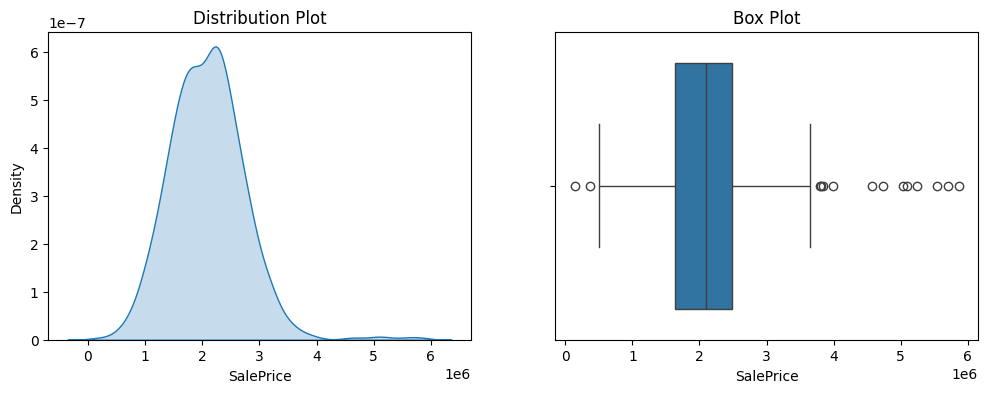

Skewness: 0.850997237637175


In [9]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

sns.kdeplot(data=data, x='SalePrice', fill=True, ax=ax[0])
ax[0].set_title('Distribution Plot')

sns.boxplot(data=data, x='SalePrice', ax=ax[1])
ax[1].set_title('Box Plot')

plt.show()

print(f"Skewness: {data['SalePrice'].skew()}")

In [10]:
print(f"Categorical Columns: {data.select_dtypes(include=['object']).columns.tolist()}")

Categorical Columns: ['Garage', 'Neighborhood', 'Condition', 'HasGarden', 'InspectionCode']


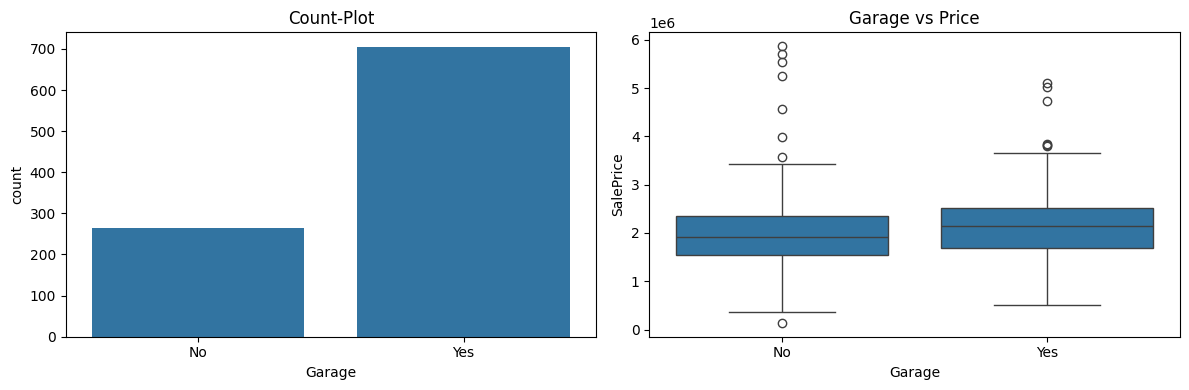

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

sns.countplot(data=data, x='Garage', ax=ax[0])
ax[0].set_title("Count-Plot")

sns.boxplot(data=data, x='Garage', y='SalePrice', ax=ax[1])
ax[1].set_title("Garage vs Price")

plt.tight_layout()
plt.show()

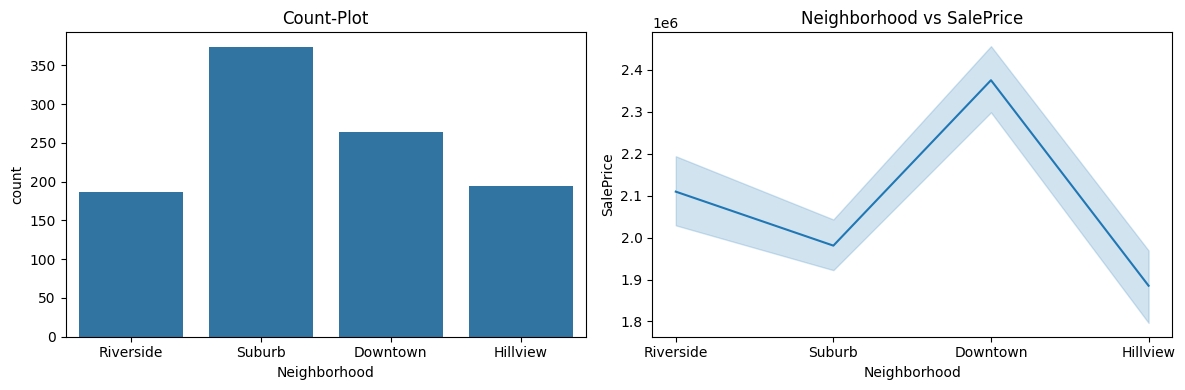

In [12]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

sns.countplot(data=data, x='Neighborhood', ax=ax[0])
ax[0].set_title("Count-Plot")

sns.lineplot(data=data, x='Neighborhood', y='SalePrice', ax=ax[1])
ax[1].set_title("Neighborhood vs SalePrice")

plt.tight_layout()
plt.show()

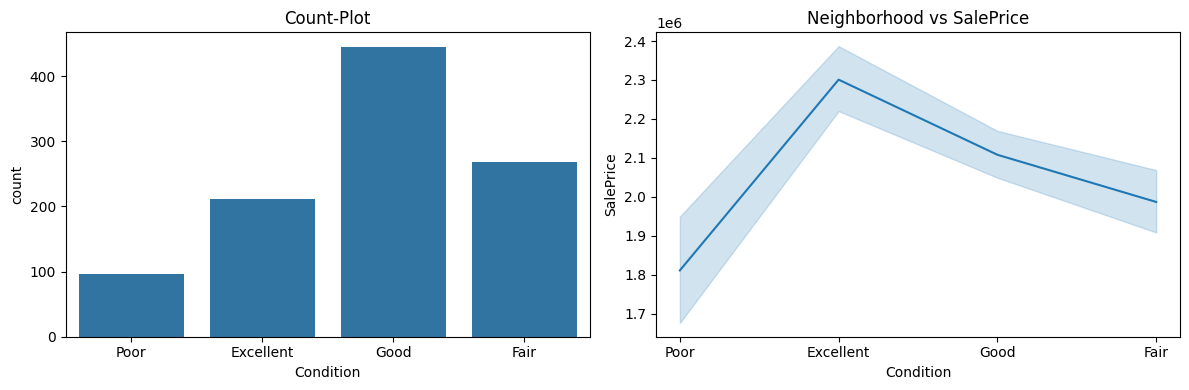

In [13]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

sns.countplot(data=data, x='Condition', ax=ax[0])
ax[0].set_title("Count-Plot")

sns.lineplot(data=data, x='Condition', y='SalePrice', ax=ax[1])
ax[1].set_title("Neighborhood vs SalePrice")

plt.tight_layout()
plt.show()

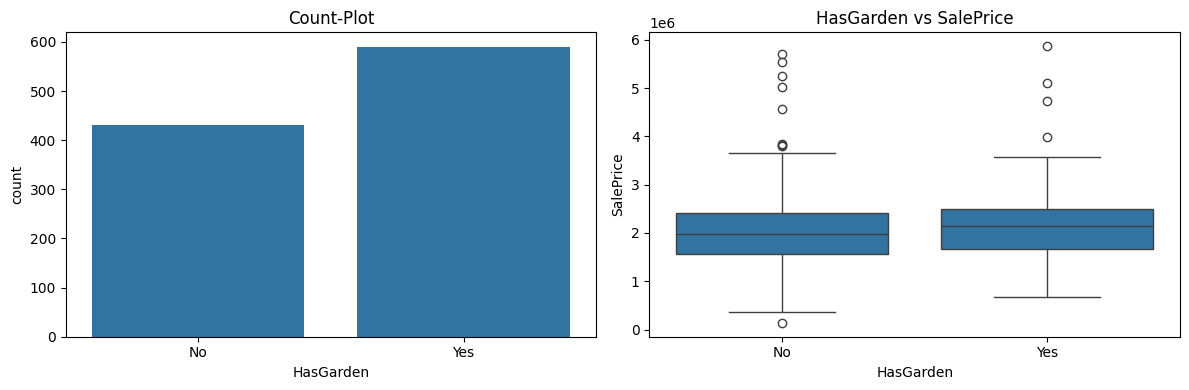

In [14]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

sns.countplot(data=data, x='HasGarden', ax=ax[0])
ax[0].set_title("Count-Plot")

sns.boxplot(data=data, x='HasGarden', y='SalePrice', ax=ax[1])
ax[1].set_title("HasGarden vs SalePrice")

plt.tight_layout()
plt.show()

In [15]:
print(f"Numerical Columns: {data.select_dtypes(include=['int', 'float']).columns.tolist()}")

Numerical Columns: ['HouseID', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'Age', 'DistanceToCity', 'MonthlyHOAFee', 'SalePrice']


In [16]:
data[['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'Age', 'DistanceToCity', 'MonthlyHOAFee', 'SalePrice']].corr()

,Area,Bedrooms,Bathrooms,Floors,Age,DistanceToCity,MonthlyHOAFee,SalePrice
Area,1.000000,-0.039989,0.064344,0.005145,-0.045815,-0.022168,0.064107,0.461162
Bedrooms,-0.039989,1.000000,-0.039220,-0.022274,-0.044777,-0.023177,-0.010083,0.531639
Bathrooms,0.064344,-0.039220,1.000000,0.041441,-0.054461,-0.040118,0.004886,0.342624
Floors,0.005145,-0.022274,0.041441,1.000000,-0.057847,0.002073,-0.005831,0.136758
Age,-0.045815,-0.044777,-0.054461,-0.057847,1.000000,-0.033955,0.027252,-0.315721
DistanceToCity,-0.022168,-0.023177,-0.040118,0.002073,-0.033955,1.000000,-0.004370,-0.209745
MonthlyHOAFee,0.064107,-0.010083,0.004886,-0.005831,0.027252,-0.004370,1.000000,0.013243
SalePrice,0.461162,0.531639,0.342624,0.136758,-0.315721,-0.209745,0.013243,1.000000


Skewness: 1.26


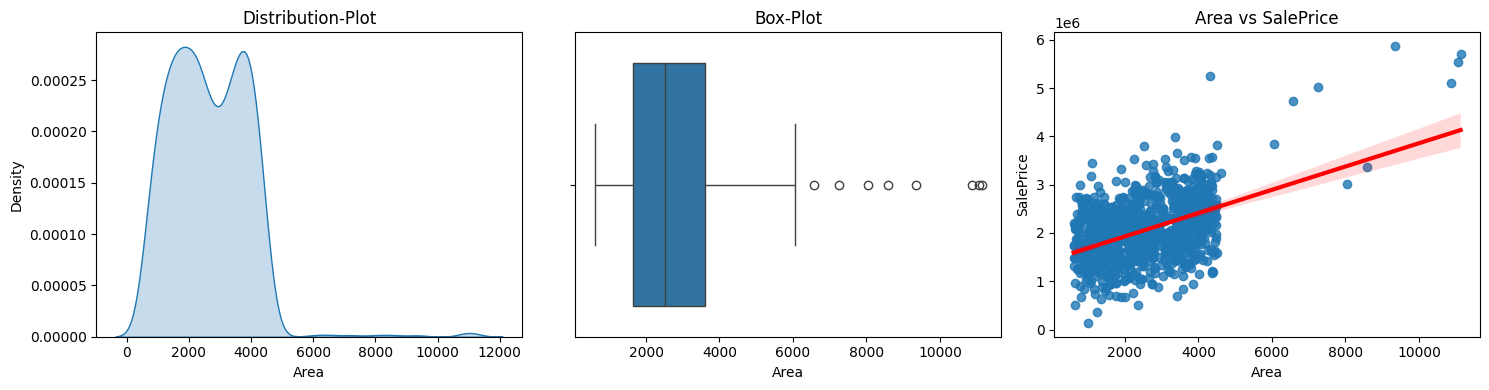

In [17]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15,4))

sns.kdeplot(data=data, x='Area', fill=True, ax=ax[0])
ax[0].set_title("Distribution-Plot")

sns.boxplot(data=data, x='Area', ax=ax[1])
ax[1].set_title("Box-Plot")

sns.regplot(data=data, x='Area', y='SalePrice', line_kws={'linewidth' : 3, 'color' : 'red'}, ax=ax[2])
ax[2].set_title("Area vs SalePrice")

print(f"Skewness: {data['Area'].skew():.2f}")

plt.tight_layout()
plt.show()

Skewness: -0.53


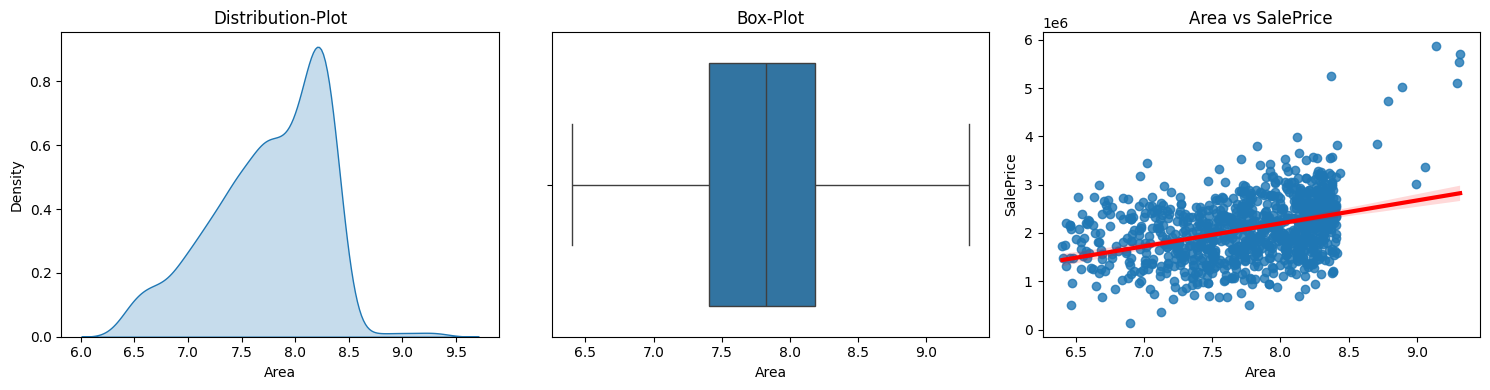

In [18]:
test_data = data.copy()

log_transform = FunctionTransformer(func=np.log1p)
test_data['Area'] = log_transform.fit_transform(test_data[['Area']])

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15,4))

sns.kdeplot(data=test_data, x='Area', fill=True, ax=ax[0])
ax[0].set_title("Distribution-Plot")

sns.boxplot(data=test_data, x='Area', ax=ax[1])
ax[1].set_title("Box-Plot")

sns.regplot(data=test_data, x='Area', y='SalePrice', line_kws={'linewidth' : 3, 'color' : 'red'}, ax=ax[2])
ax[2].set_title("Area vs SalePrice")

print(f"Skewness: {test_data['Area'].skew():.2f}")

plt.tight_layout()
plt.show()

In [19]:
test_data[['Area', 'SalePrice']].corr()

,Area,SalePrice
Area,1.000000,0.374494
SalePrice,0.374494,1.000000


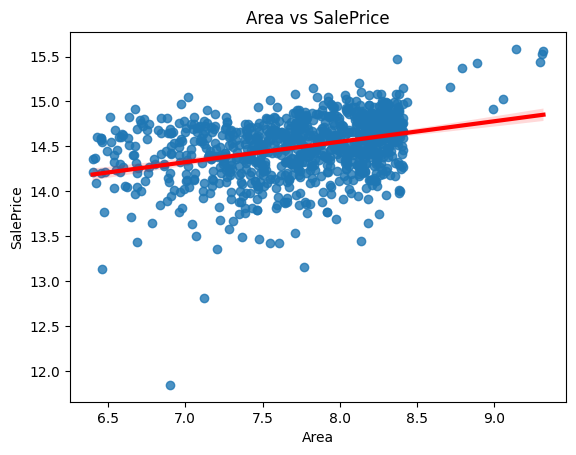

In [20]:
log_data = data.copy()

transform = FunctionTransformer(func=np.log1p)
log_data['Area'] = transform.fit_transform(log_data[['Area']])
log_data['SalePrice'] = transform.fit_transform(log_data[['SalePrice']])

sns.regplot(data=log_data, x='Area', y='SalePrice', line_kws={'linewidth' : 3, 'color' : 'red'})
plt.title("Area vs SalePrice")

plt.show()

In [21]:
log_data[['Area', 'SalePrice']].corr()

,Area,SalePrice
Area,1.000000,0.348317
SalePrice,0.348317,1.000000


Skewness: 0.06


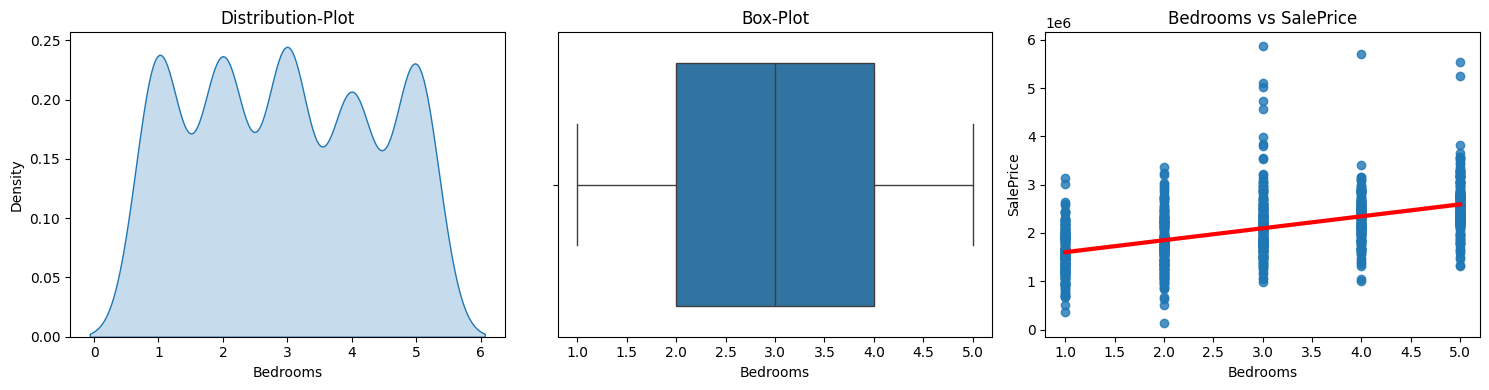

In [22]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15,4))

sns.kdeplot(data=data, x='Bedrooms', fill=True, ax=ax[0])
ax[0].set_title("Distribution-Plot")

sns.boxplot(data=data, x='Bedrooms', ax=ax[1])
ax[1].set_title("Box-Plot")

sns.regplot(data=data, x='Bedrooms', y='SalePrice', line_kws={'linewidth' : 3, 'color' : 'red'}, ax=ax[2])
ax[2].set_title("Bedrooms vs SalePrice")

print(f"Skewness: {data['Bedrooms'].skew():.2f}")

plt.tight_layout()
plt.show()

Skewness: 0.06


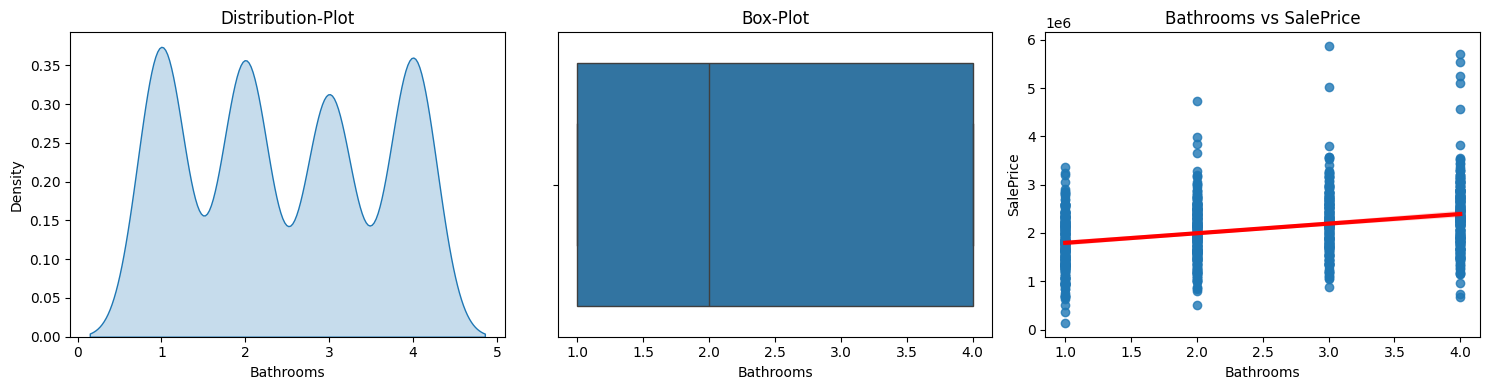

In [23]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15,4))

sns.kdeplot(data=data, x='Bathrooms', fill=True, ax=ax[0])
ax[0].set_title("Distribution-Plot")

sns.boxplot(data=data, x='Bathrooms', ax=ax[1])
ax[1].set_title("Box-Plot")

sns.regplot(data=data, x='Bathrooms', y='SalePrice', line_kws={'linewidth' : 3, 'color' : 'red'}, ax=ax[2])
ax[2].set_title("Bathrooms vs SalePrice")

print(f"Skewness: {data['Bathrooms'].skew():.2f}")

plt.tight_layout()
plt.show()

Skewness: 0.01


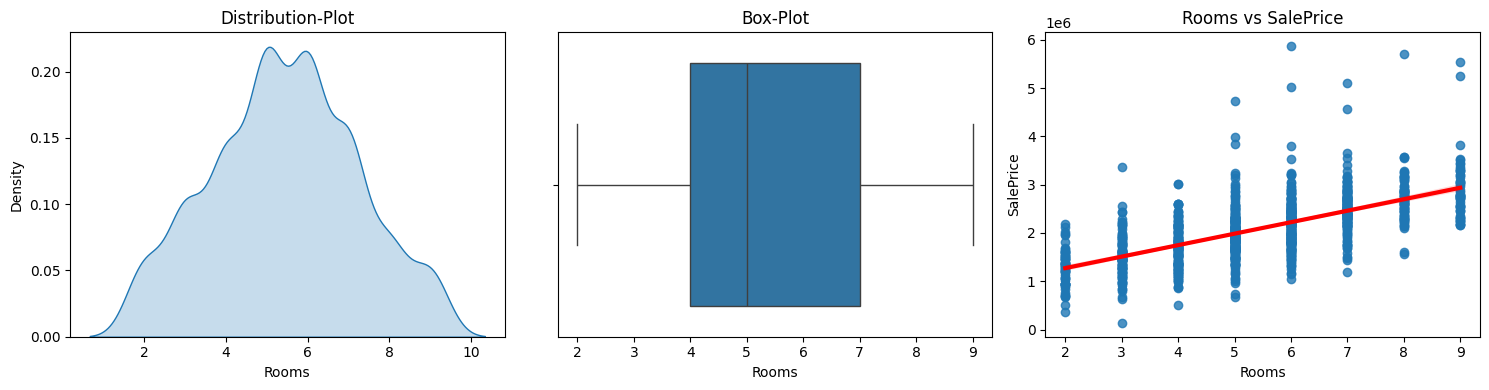

In [24]:
# New Feature:

test_data['Rooms'] = test_data['Bedrooms'] + test_data['Bathrooms']

test_data.drop(columns=['Bedrooms', 'Bathrooms'], inplace=True)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15,4))

sns.kdeplot(data=test_data, x='Rooms', fill=True, ax=ax[0])
ax[0].set_title("Distribution-Plot")

sns.boxplot(data=test_data, x='Rooms', ax=ax[1])
ax[1].set_title("Box-Plot")

sns.regplot(data=test_data, x='Rooms', y='SalePrice', line_kws={'linewidth' : 3, 'color' : 'red'}, ax=ax[2])
ax[2].set_title("Rooms vs SalePrice")

print(f"Skewness: {test_data['Rooms'].skew():.2f}")

plt.tight_layout()
plt.show()

In [25]:
test_data[['Rooms', 'SalePrice']].corr()

,Rooms,SalePrice
Rooms,1.000000,0.641511
SalePrice,0.641511,1.000000


Skewness: 0.03


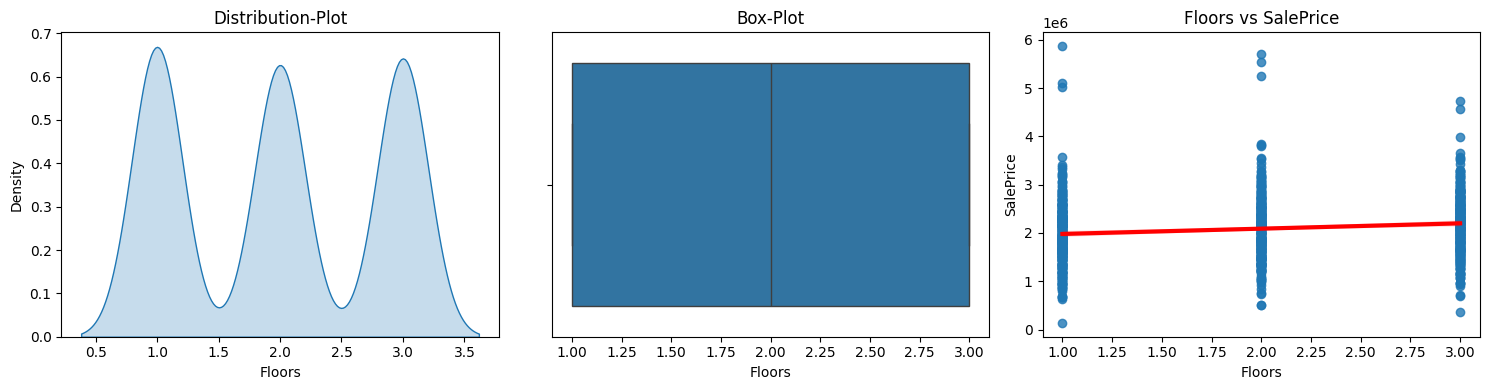

In [26]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15,4))

sns.kdeplot(data=data, x='Floors', fill=True, ax=ax[0])
ax[0].set_title("Distribution-Plot")

sns.boxplot(data=data, x='Floors', ax=ax[1])
ax[1].set_title("Box-Plot")

sns.regplot(data=data, x='Floors', y='SalePrice', line_kws={'linewidth' : 3, 'color' : 'red'}, ax=ax[2])
ax[2].set_title("Floors vs SalePrice")

print(f"Skewness: {data['Floors'].skew():.2f}")

plt.tight_layout()
plt.show()

Skewness: 0.00


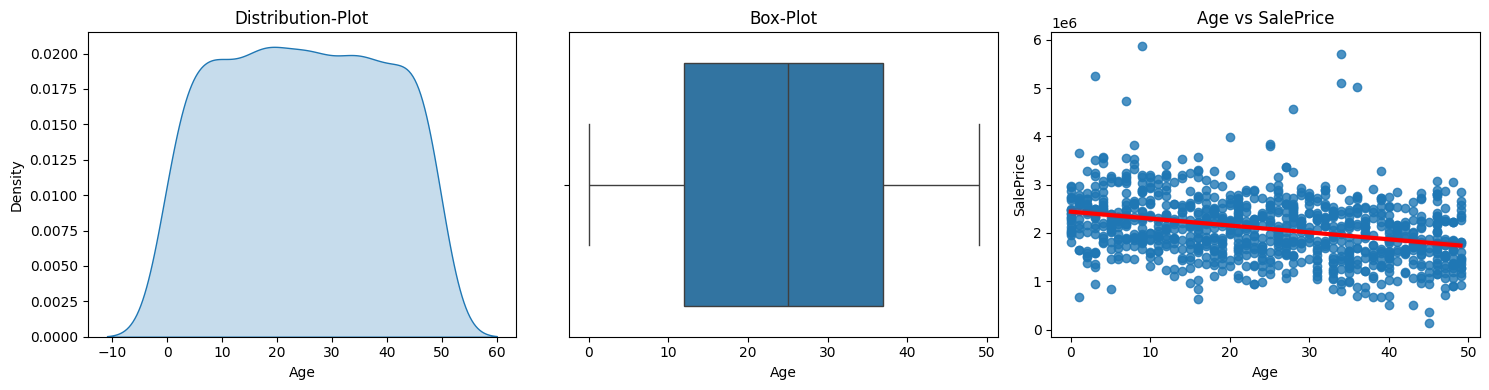

In [27]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15,4))

sns.kdeplot(data=data, x='Age', fill=True, ax=ax[0])
ax[0].set_title("Distribution-Plot")

sns.boxplot(data=data, x='Age', ax=ax[1])
ax[1].set_title("Box-Plot")

sns.regplot(data=data, x='Age', y='SalePrice', line_kws={'linewidth' : 3, 'color' : 'red'}, ax=ax[2])
ax[2].set_title("Age vs SalePrice")

print(f"Skewness: {data['Age'].skew():.2f}")

plt.tight_layout()
plt.show()

Skewness: 0.06


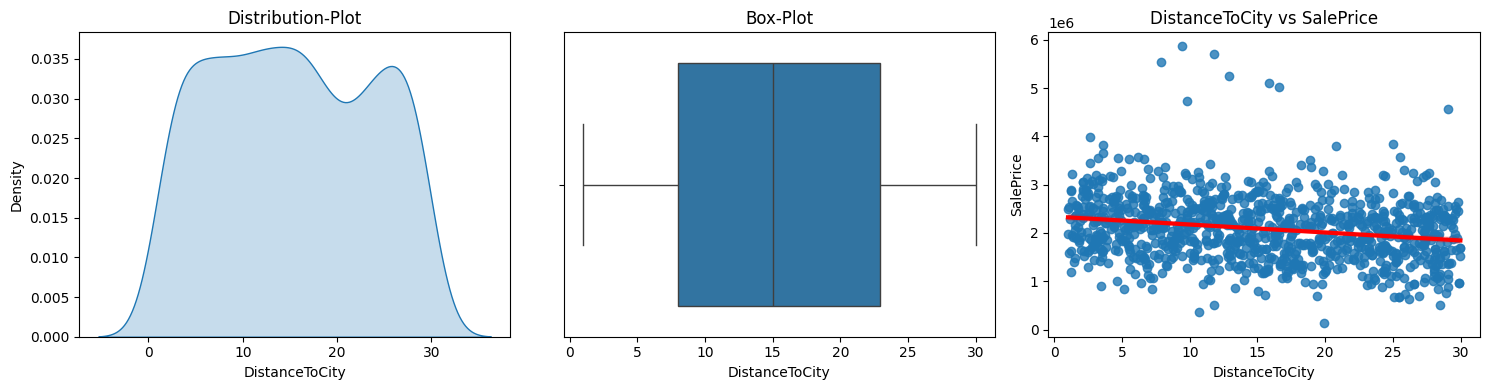

In [28]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15,4))

sns.kdeplot(data=data, x='DistanceToCity', fill=True, ax=ax[0])
ax[0].set_title("Distribution-Plot")

sns.boxplot(data=data, x='DistanceToCity', ax=ax[1])
ax[1].set_title("Box-Plot")

sns.regplot(data=data, x='DistanceToCity', y='SalePrice', line_kws={'linewidth' : 3, 'color' : 'red'}, ax=ax[2])
ax[2].set_title("DistanceToCity vs SalePrice")

print(f"Skewness: {data['DistanceToCity'].skew():.2f}")

plt.tight_layout()
plt.show()

Skewness: 0.02


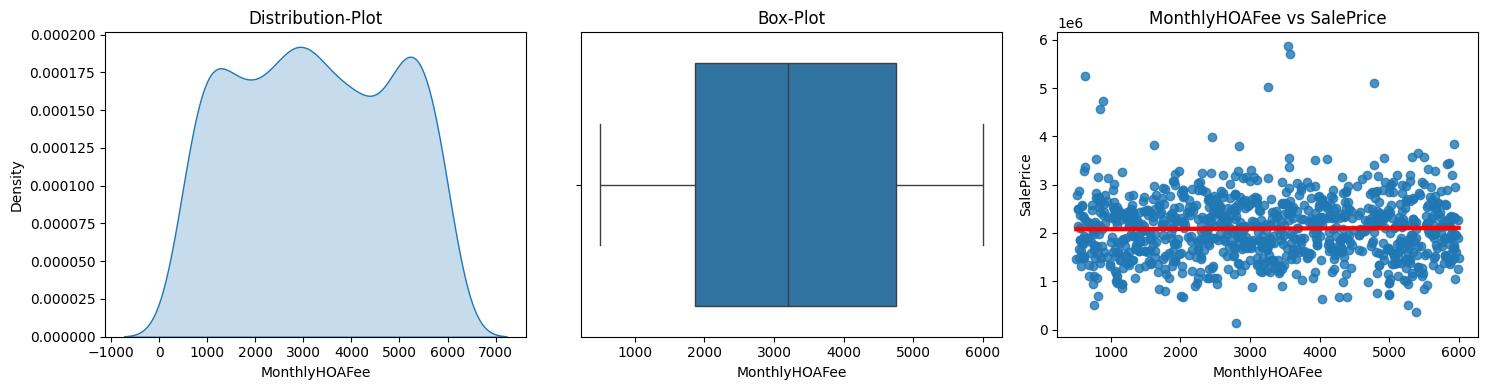

In [29]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15,4))

sns.kdeplot(data=test_data, x='MonthlyHOAFee', fill=True, ax=ax[0])
ax[0].set_title("Distribution-Plot")

sns.boxplot(data=test_data, x='MonthlyHOAFee', ax=ax[1])
ax[1].set_title("Box-Plot")

sns.regplot(data=test_data, x='MonthlyHOAFee', y='SalePrice', line_kws={'linewidth' : 3, 'color' : 'red'}, ax=ax[2])
ax[2].set_title("MonthlyHOAFee vs SalePrice")

print(f"Skewness: {test_data['MonthlyHOAFee'].skew():.2f}")

plt.tight_layout()
plt.show()

---

# Summary:

- **Target Feature:** *SalePrice*.

- **Input Features (Numerical):**
| Features | Feature Engineering |
| - | - |
| Bedrooms , Bathrooms | (Rooms = Bedrooms + bathrooms) + Drop |
| MonthlyHoaFee | Drop |
| Floors | Drop |
| Area | SimpleImputer(median) |
| Age | SimpleImputer(median) |

- **Input Features (Categorical):**
| Features | Feature Engineering |
| - | - |
| Garage | SimpleImputer(most_frequent) + OneHotEncode |
| Neighborhood | OneHotEncode |
| Condition | OneHotEncode |
| HasGarden | OneHotEncode |

- There are no duplicated values.